# Lecture 6: estimating a covariance matrix

We fit **two parameters**, an intercept and a slope, to a noisy data vector.
The data covariance is usually estimated from simulations. How does that change
the scatter of our best fits and the uncertainty reported by a posterior?

1. Compare the covariance of repeated maximum-likelihood estimates (MLEs) with
   the inverse Fisher matrix and its Dodelson–Schneider correction.
2. Sample three posteriors: the true Gaussian, a Hartlap-corrected Gaussian,
   and the Percival (2021) matching posterior.
3. Change the data seed, repeat the experiment, and measure credible-region coverage.

## Setup

Use the existing `tutorials/.venv` environment as the notebook kernel. From the
repository root, start Jupyter with:

```bash
cd tutorials
source .venv/bin/activate
python -m jupyterlab
```

For a new environment, run `uv venv --python 3.12` and
`uv pip install --python .venv -r requirements.txt` from `tutorials/` first.
On Windows PowerShell use `.venv\Scripts\Activate.ps1` to activate it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lecture_06_helpers import (
    plot_covariances, plot_mle_scatter, plot_variance_comparison,
    plot_data, plot_posteriors, plot_posterior_grid, plot_coverage,
    sample_posterior,
)

np.set_printoptions(precision=4, suppress=True)

## Controls: change a seed and run all cells

`data_seed` changes the observed data **and** the posterior draws.
`covariance_seed` controls the independent covariance mocks. Leave it fixed to
isolate the effect of changing the observed data. `experiment_seed` controls the
large repeated-experiment study.

To rerun the single-data posterior comparison, edit `data_seed`, execute the
controls cell below, then rerun from **Section 4** onward. The earlier simulations
do not depend on this seed.

In [2]:
data_seed = 606
covariance_seed = 607
experiment_seed = 608
n_s = 40                         # Independent mocks used for one covariance estimate.
mock_counts = [24, 40, 80, 160, 400]
n_experiments = 2000             # Independent experiments, not posterior draws.
level = 0.95                     # Joint posterior probability for BOTH parameters.

def rng_for(seed, stream):
    # Different stream identifiers separate independent random draws.
    return np.random.default_rng(np.random.SeedSequence([seed, stream]))

## 1. One data vector; two fitted parameters

At 12 fixed positions, measure

$$x_i=\theta_1+\theta_2t_i+\epsilon_i,\qquad
\boldsymbol\epsilon\sim\mathcal N_{d}(0,C),\qquad d=12,\quad p=2.$$

The mean is $J\theta$, with columns $1$ and $t$. We know $C$ in this simulation
so we can check the result. All observations and mocks are generated with this
same $C$, independently of one another. The true parameters stay fixed.

There are more data components than fitted parameters. An unrestricted 2D mean
fitted to a single 2D observation would reproduce it exactly, hiding the effect
of covariance weighting on the best fit.

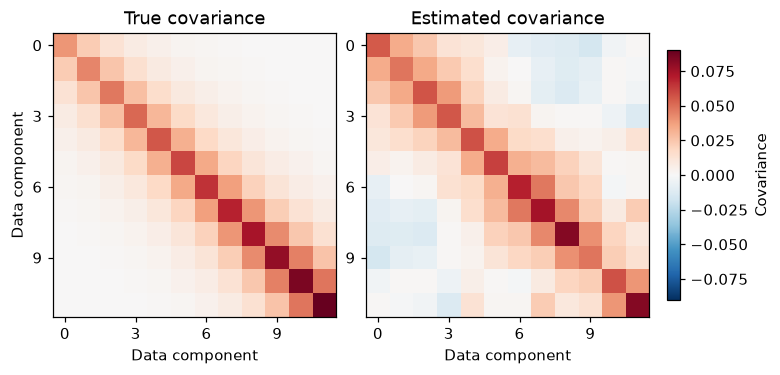

In [3]:
d, p = 12, 2
t = np.linspace(-1, 1, d)
J = np.column_stack([np.ones(d), t])
theta_true = np.array([1.0, 0.4])
sigma = 0.25 * (1 + 0.2 * t)
index = np.arange(d)
C = sigma[:, None] * sigma[None, :] * 0.55 ** np.abs(index[:, None] - index[None, :])
chol_C = np.linalg.cholesky(C)

def draw_data(rng, size=None):
    shape = (d,) if size is None else (size, d)
    return J @ theta_true + rng.standard_normal(shape) @ chol_C.T

def sample_covariance(mocks):
    centred = mocks - mocks.mean(axis=0)
    return centred.T @ centred / (len(mocks) - 1)

assert n_s > d + 4 and all(count > d + 4 for count in mock_counts)
mocks = draw_data(rng_for(covariance_seed, 1), n_s)
S = sample_covariance(mocks)
plot_covariances(C, S)
plt.show()

**Look and discuss.** Increase `n_s`, then change `covariance_seed`. Does an unbiased covariance estimate equal the true covariance in every experiment?

## 2. Covariance of MLEs and the Fisher prediction

For any positive-definite weighting covariance $A$, the linear Gaussian fit is

$$\widehat\theta_A=(J^{\mathsf T}A^{-1}J)^{-1}J^{\mathsf T}A^{-1}x.$$

With the true covariance, $F=J^{\mathsf T}C^{-1}J$ and
$\operatorname{Cov}(\widehat\theta_C)=F^{-1}$ exactly in this linear model.
We compare a parameter covariance with **$F^{-1}$**, because $F$ is a precision.

First hold one estimated $S$ fixed and redraw only the data. If
$K_S=(J^{\mathsf T}S^{-1}J)^{-1}J^{\mathsf T}S^{-1}$, the actual covariance is
$K_S C K_S^{\mathsf T}$. It generally differs from the inverse curvature
$(J^{\mathsf T}S^{-1}J)^{-1}$ reported by a plug-in Gaussian fit.

The curves below are covariance ellipses at squared Mahalanobis radius 1.

Fisher matrix F:
 [[ 71.5301 -15.2817]
 [-15.2817  41.9832]]
Ideal covariance F^-1:
 [[0.0152 0.0055]
 [0.0055 0.0258]]
Empirical covariance using C:
 [[0.0151 0.0057]
 [0.0057 0.0253]]
Empirical covariance using fixed S:
 [[0.0179 0.0074]
 [0.0074 0.0311]]


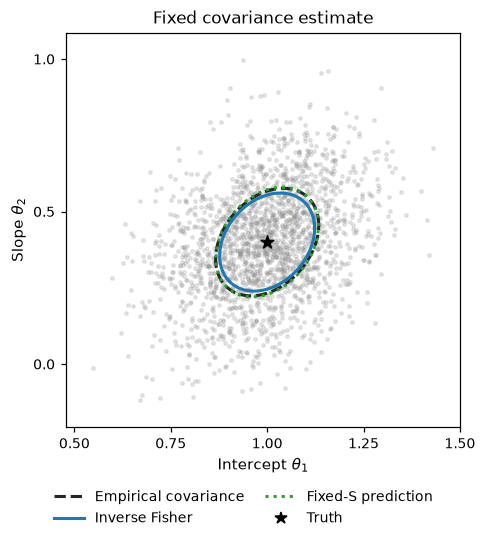

In [4]:
def fit_matrix(covariance):
    weighted_J = np.linalg.solve(covariance, J)
    curvature = J.T @ weighted_J
    K = np.linalg.solve(curvature, weighted_J.T)
    width = np.linalg.solve(curvature, np.eye(p))
    return K, width

K_true, F_inverse = fit_matrix(C)
F = J.T @ np.linalg.solve(C, J)
K_S, raw_width = fit_matrix(S)
fixed_data = draw_data(rng_for(experiment_seed, 2), n_experiments)
ideal_mles = fixed_data @ K_true.T
fixed_mles = fixed_data @ K_S.T
fixed_covariance = np.cov(fixed_mles, rowvar=False)
conditional_covariance = K_S @ C @ K_S.T

print('Fisher matrix F:\n', F)
print('Ideal covariance F^-1:\n', F_inverse)
print('Empirical covariance using C:\n', np.cov(ideal_mles, rowvar=False))
print('Empirical covariance using fixed S:\n', fixed_covariance)
plot_mle_scatter(fixed_mles, theta_true, {
    'Empirical covariance': fixed_covariance,
    'Inverse Fisher': F_inverse,
    'Exact covariance at fixed S': conditional_covariance,
}, title='Fixed covariance estimate')
plt.show()

**Look and discuss.** What varies between the points? Is this cloud a posterior?

## 3. Redraw the covariance estimate as well

Now each experiment gets a fresh data vector **and** an independent set of
$n_s$ mocks. Dodelson & Schneider predict the approximate MLE covariance

$$V_{\rm DS}=f_{\rm DS}F^{-1},\qquad
f_{\rm DS}=1+B(d-p),\qquad
B=\frac{n_s-d-2}{(n_s-d-1)(n_s-d-4)}.$$

Equivalently, a Fisher matrix adjusted to predict this scatter is
$F_{\rm DS}=F/f_{\rm DS}$. This is an ensemble scatter correction; it is not
the curvature of a particular likelihood. We require $n_s>d+4$ throughout.

For this exactly linear Gaussian example we also know the exact ensemble factor
$f_{\rm exact}=1+(d-p)/(n_s-d+p-2)$. It lets us see the small finite-mock error
of the DS approximation. Both approach 1 as the mock count increases.
The [lecture derivation](../06_cov_est/dodelson_schneider_derivation.md)
explains the distinction.

The variance plot divides by the ideal variance. Bars show two Monte Carlo
standard errors.

n_s = 40; empirical covariance:
 [[0.0206 0.0072]
 [0.0072 0.0354]]
Dodelson–Schneider covariance prediction:
 [[0.0212 0.0077]
 [0.0077 0.0362]]


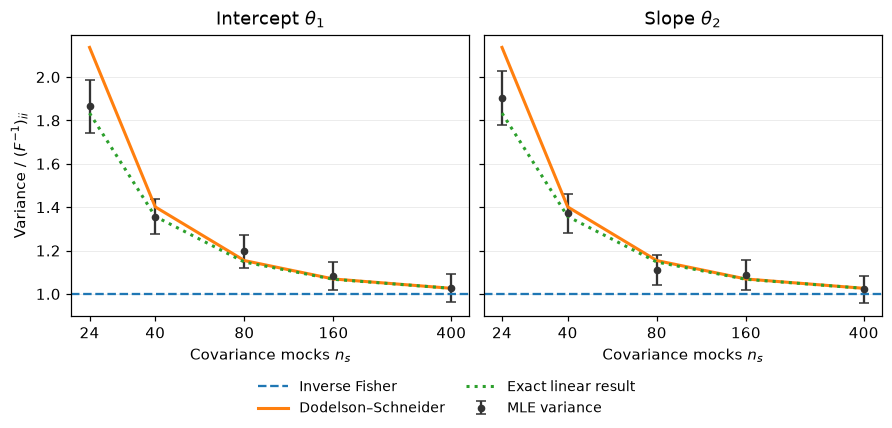

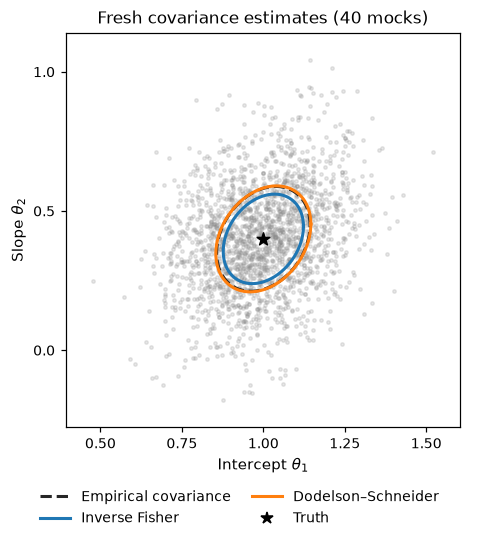

In [5]:
def correction_factors(n_mock):
    if n_mock <= d + 4:
        raise ValueError(f'Use n_s > d + 4 = {d + 4}.')
    h = (n_mock - d - 2) / (n_mock - 1)
    B = (n_mock - d - 2) / ((n_mock - d - 1) * (n_mock - d - 4))
    f_DS = 1 + B * (d - p)
    f_exact = 1 + (d - p) / (n_mock - d + p - 2)
    m = p + 2 + (n_mock - 1 + B * (d - p)) / f_DS
    return h, f_DS, f_exact, m

def repeat_experiments(n_mock, seed, fixed_S=None):
    data_rng, mock_rng = rng_for(seed, 2), rng_for(seed, 3)
    data = draw_data(data_rng, n_experiments)
    covariances, estimates = [], []
    for x in data:
        S_i = (sample_covariance(draw_data(mock_rng, n_mock))
               if fixed_S is None else fixed_S)
        K_i, _ = fit_matrix(S_i)
        estimates.append(K_i @ x)
        covariances.append(S_i)
    return {'data': data, 'S': np.array(covariances),
            'mles': np.array(estimates), 'n_s': n_mock}

# Store the data and covariance estimates so we can reuse them for coverage.
repetitions = {count: repeat_experiments(count, experiment_seed + count)
               for count in sorted(set(mock_counts + [n_s]))}
empirical_covariances, variance_se = [], []
for count in mock_counts:
    estimates = repetitions[count]['mles']
    empirical_covariances.append(np.cov(estimates, rowvar=False))
    # Approximate MC standard error of each sample variance, allowing non-Gaussian scatter.
    squares = (estimates - estimates.mean(axis=0)) ** 2
    variance_se.append(squares.std(axis=0, ddof=1) / np.sqrt(n_experiments))

ds_factors = [correction_factors(count)[1] for count in mock_counts]
exact_factors = [correction_factors(count)[2] for count in mock_counts]
plot_variance_comparison(mock_counts, np.array(empirical_covariances),
                        np.array(variance_se), F_inverse, ds_factors, exact_factors)
plt.show()

fresh_mles = repetitions[n_s]['mles']
V_DS = correction_factors(n_s)[1] * F_inverse
F_DS = F / correction_factors(n_s)[1]
print(f'n_s = {n_s}; empirical covariance:\n', np.cov(fresh_mles, rowvar=False))
print('Dodelson–Schneider covariance prediction:\n', V_DS)
plot_mle_scatter(fresh_mles, theta_true, {
    'Empirical covariance': np.cov(fresh_mles, rowvar=False),
    'Inverse Fisher': F_inverse,
    'Dodelson–Schneider': V_DS,
}, title=f'Fresh covariance estimates ({n_s} mocks)')
plt.show()

**Look and discuss.** Why do more mocks reduce the excess scatter without reducing the ideal Fisher covariance? Why does DS fit the fresh-S experiment better than one arbitrary fixed-S experiment?

## 4. Three posteriors for the same observed data

Use a flat prior on $(\theta_1,\theta_2)\in\mathbb R^2$. It is improper, but all
three parameter posteriors below are proper. The matching prescription concerns
the prior on the unknown **data covariance**. We keep the parameter prior flat.

Write $r=x-J\theta$, $Q_C=r^{\mathsf T}C^{-1}r$, and
$Q_S=r^{\mathsf T}S^{-1}r$. Up to parameter-independent constants:

- **True Gaussian:** $\log P=-Q_C/2$.
- **Hartlap Gaussian:** $\log P=-hQ_S/2$, with $h=(n_s-d-2)/(n_s-1)$.
- **Percival 2021:** $\log P=-\frac m2\log[1+Q_S/(n_s-1)]$, where
$$m=p+2+\frac{n_s-1+B(d-p)}{1+B(d-p)}.$$

The Hartlap factor debiases the estimated precision in an ensemble average.
It rescales a Gaussian posterior's width and leaves its peak unchanged.
Percival uses the **unscaled** $S^{-1}$, with no additional Hartlap factor.
Its full $Q_S$, including its nonzero minimum, must stay inside the logarithm.
See [Percival et al., equations 52–55](https://arxiv.org/html/2108.10402v2#S7)
(2021 preprint; published 2022).

Error bars show marginal noise SD; measurement errors are correlated.


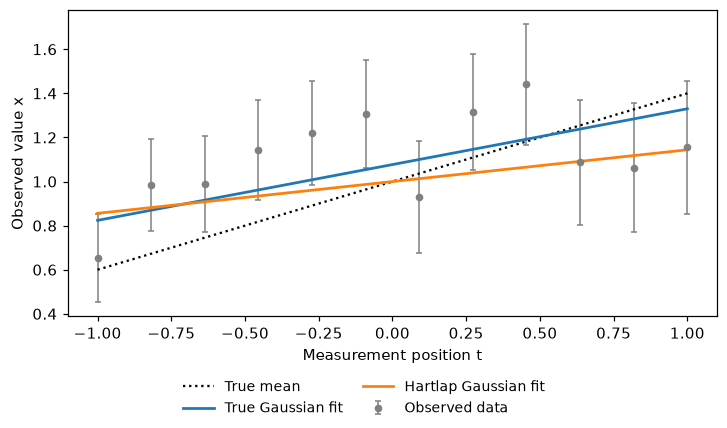

In [6]:
def posterior_models(x, S_estimate, n_mock):
    h, _, _, m = correction_factors(n_mock)
    K, width = fit_matrix(S_estimate)
    peak = K @ x
    precision = np.linalg.solve(S_estimate, np.eye(d))
    true_precision = np.linalg.solve(C, np.eye(d))
    residual = x - J @ peak
    Q_min = residual @ precision @ residual
    nu = m - p
    t_scale = (n_mock - 1 + Q_min) * width / nu

    def Q(theta, P):
        r = x - J @ theta
        return r @ P @ r

    return {
        'True Gaussian': dict(mean=K_true @ x, scale=F_inverse,
                              covariance=F_inverse, df=np.inf,
                              log_density=lambda theta: -0.5 * Q(theta, true_precision)),
        'Hartlap Gaussian': dict(mean=peak, scale=width / h,
                                 covariance=width / h, df=np.inf,
                                 log_density=lambda theta: -0.5 * h * Q(theta, precision)),
        'Percival 2021': dict(mean=peak, scale=t_scale,
                              covariance=t_scale * nu / (nu - 2), df=nu,
                              log_density=lambda theta: -0.5 * m * np.log1p(
                                  Q(theta, precision) / (n_mock - 1))),
    }

# Recreate both objects here so this section can be rerun after changing data_seed.
x = draw_data(rng_for(data_seed, 0))
S = sample_covariance(draw_data(rng_for(covariance_seed, 1), n_s))
posteriors = posterior_models(x, S, n_s)

plot_data(t, x, C, J, theta_true, posteriors)
plt.show()
print('Error bars show marginal noise SD; measurement errors are correlated.')

### Exact joint regions for two parameters

The first two posteriors are Gaussian. The Percival parameter posterior is
Student-t with centre $\widehat\theta_S$, degrees of freedom $\nu=m-p$, and
**scale**

$$R=\frac{n_s-1+Q_{\min}}{\nu}(J^{\mathsf T}S^{-1}J)^{-1}.$$

Its covariance is $\nu R/(\nu-2)$, so scale and covariance are different.
An HPD region contains the highest posterior densities with total mass $q$.
For two parameters its boundary has squared distance
$u=(\theta-\widehat\theta)^{\mathsf T}R^{-1}(\theta-\widehat\theta)$ equal to

$$u_q=\nu[(1-q)^{-2/\nu}-1].$$

For a Gaussian, use its covariance in place of $R$ and $u_q=-2\log(1-q)$.
These are **joint** regions for both parameters. We use the exact boundaries
in the plots and the coverage study.

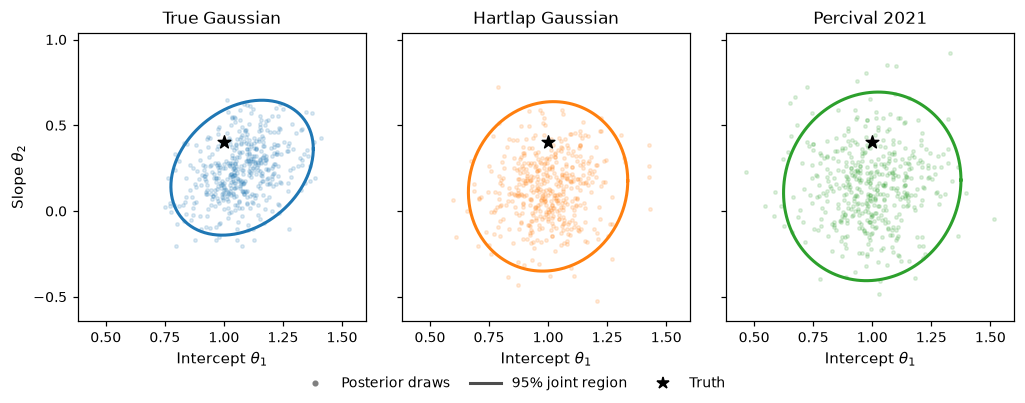

In [7]:
def region_radius_squared(model, probability=0.95):
    if not 0 < probability < 1:
        raise ValueError('Region probability must lie strictly between 0 and 1.')
    nu = model['df']
    if np.isinf(nu):
        return -2 * np.log1p(-probability)
    return nu * np.expm1(-2 * np.log1p(-probability) / nu)

def in_region(points, model, probability=0.95):
    delta = np.asarray(points) - model['mean']
    whitened = np.linalg.solve(np.linalg.cholesky(model['scale']), delta.T).T
    return np.sum(whitened ** 2, axis=-1) <= region_radius_squared(model, probability)

samples = {
    label: sample_posterior(model, seed=data_seed, stream=10 + i)
    for i, (label, model) in enumerate(posteriors.items())
}
plot_posteriors(posteriors, theta_true, samples=samples, level=level)
plt.show()

**Look and discuss.** Which two posteriors have exactly the same peak? Must the true parameters lie inside every 95% region?

## 5. Several experiments side by side

Each column uses a new data seed. The rows use different mock budgets. The
observed vector is identical down each column, and the same covariance seed is
used throughout. Within a row, all columns hold one covariance estimate fixed.
These panels show the exact posterior regions for each dataset and mock count.

Try nearby seeds without searching only for a particularly good or bad result.
The next section measures what happens across many independent experiments.

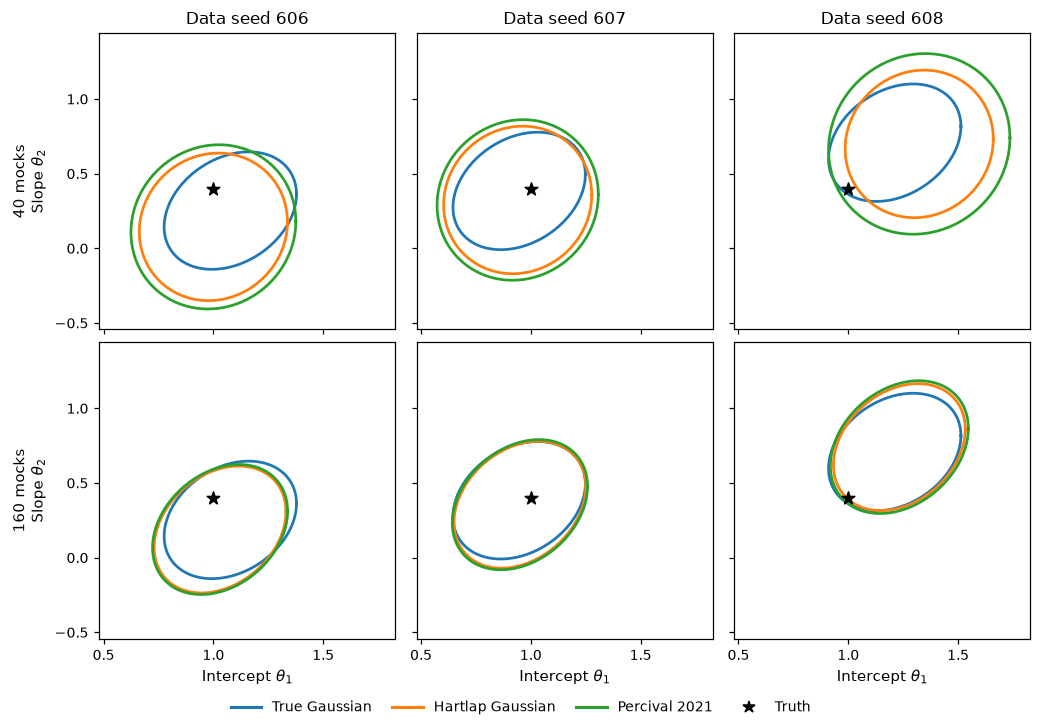

In [8]:
comparison_seeds = [data_seed, data_seed + 1, data_seed + 2]
comparison_counts = [40, 160]
cases = []
for count in comparison_counts:
    S_case = sample_covariance(draw_data(rng_for(covariance_seed, 1), count))
    cases.append([
        posterior_models(draw_data(rng_for(seed, 0)), S_case, count)
        for seed in comparison_seeds
    ])

plot_posterior_grid(cases, theta_true, seeds=comparison_seeds,
                    mock_counts=comparison_counts, level=level)
plt.show()

**Look and discuss.** When only the data change, do all posterior widths stay fixed? What happens as the mock budget increases?

## 6. Repeated-experiment coverage

For each dataset, construct a joint region of posterior mass `level`, then ask
whether it contains the fixed truth. The fraction of hits estimates coverage.
The exact region boundaries let us calculate coverage directly.

Compare two experiments:

- **Fixed S:** fresh data, using the same realised covariance estimate each time.
- **Fresh S:** fresh data and fresh independent covariance mocks each time.

Percival's prescription targets approximate ensemble matching of parameter
covariances. It is not an exact coverage guarantee for each fixed S, every mock
count, or every credible probability. Error bars show two Monte Carlo standard
errors from independent experiments; they describe simulation uncertainty.

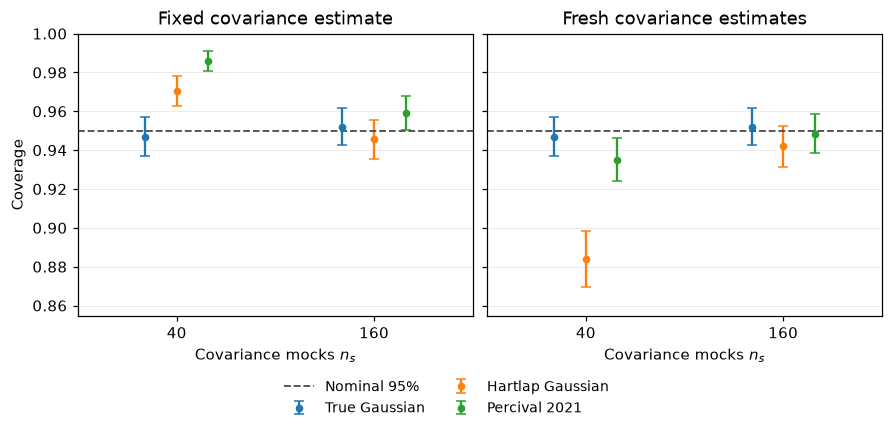

In [9]:
def coverage_for(batch):
    hits = {label: [] for label in posteriors}
    for x_i, S_i in zip(batch['data'], batch['S']):
        models = posterior_models(x_i, S_i, batch['n_s'])
        for label, model in models.items():
            hits[label].append(bool(in_region(theta_true, model, level)))
    results = {}
    for label, values in hits.items():
        fraction = np.mean(values)
        se = np.sqrt(fraction * (1 - fraction) / len(values))
        results[label] = (fraction, se)
    return results

coverage_results = {}
for count in comparison_counts:
    S_fixed = sample_covariance(draw_data(rng_for(covariance_seed, 1), count))
    fixed_batch = repeat_experiments(count, experiment_seed + count, fixed_S=S_fixed)
    fresh_batch = repetitions.get(count)
    if fresh_batch is None:
        fresh_batch = repeat_experiments(count, experiment_seed + count)
    # The paired studies use identical data, with different covariance-redraw rules.
    coverage_results[f'Fixed S, n_s={count}'] = coverage_for(fixed_batch)
    coverage_results[f'Fresh S, n_s={count}'] = coverage_for(fresh_batch)

plot_coverage(coverage_results, level=level)
plt.show()

**Look and discuss.** Does correcting the bias of the precision automatically give correctly calibrated posterior regions? Which repetitions address the DS calculation?

## What to remember

$C$ describes measurement noise, and $S$ estimates it from mocks. The inverse
Fisher matrix predicts ideal MLE scatter; the DS correction accounts for the
extra scatter caused by estimating the covariance.

A posterior describes parameter uncertainty for one dataset. Coverage measures
how often regions from repeated experiments contain the truth.

**Try next:** change `n_s`, `data_seed`, `covariance_seed`, or `level` one at a
time. More covariance mocks improve the covariance estimate; more repeated
experiments improve the precision of the measured scatter and coverage.

### References

- [Dodelson & Schneider (2013)](https://arxiv.org/abs/1304.2593): covariance-estimation noise and parameter scatter.
- [Hartlap, Simon & Schneider (2007)](https://arxiv.org/abs/astro-ph/0608064): bias of an estimated inverse covariance.
- [Percival et al. (2021 preprint; 2022 publication)](https://arxiv.org/abs/2108.10402): matching posterior, equations 51–55.
- [Lecture derivation](../06_cov_est/dodelson_schneider_derivation.md): conditional covariance, DS approximation, and exact linear benchmark.